# Proyecto de Magíster: Detección de Anomalías y Posibles Fraudes en Permisos de Circulación

## Problemática
En la administración municipal, el cobro de los Permisos de Circulación Vehicular depende fuertemente de datos ingresados manualmente y tasaciones. Debido a la falta de validación estandarizada en los sistemas locales, existen múltiples errores de digitación, inconsistencias de formato y, potencialmente, **fraudes y evasiones** (por ejemplo, vehículos de alto valor comercial registrados con características alteradas para pagar menos, o modificaciones vehiculares no declaradas). Esta desestructuración de la información genera ineficiencias en la gestión pública y grandes pérdidas de ingresos municipales.

## Objetivo General
Desarrollar un pipeline de datos y un modelo de Machine Learning basado en **Aprendizaje No Supervisado (Detección de Anomalías)** para identificar patrones inusuales y registros atípicos en la base de datos de permisos de circulación, permitiendo alertar a la municipalidad sobre posibles fraudes o errores graves de tasación.

## Objetivos Específicos
1. Cargar y realizar una exploración inicial de los datos municipales (EDA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import os

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.0f}'.format

import warnings
warnings.filterwarnings('ignore')

# Si el notebook se abre desde el directorio notebook/, subir a la raíz del proyecto
if os.path.basename(os.getcwd()) == 'notebook':
    os.chdir('..')

file_path = 'datos/original/permiso-circulacion-2026.csv'

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 1. Carga de Datos
Lectura del archivo CSV y construcción del DataFrame de trabajo.

In [2]:
def cargar_datos(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"\n[ERROR] No se encontró el archivo: '{file_path}'\n"
            f"Verifica que el CSV esté en la ruta correcta antes de continuar."
        )
    df = pd.read_csv(file_path, encoding='utf-8')
    print(f"Dataset cargado exitosamente. Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas.")
    return df

df = cargar_datos(file_path)

Dataset cargado exitosamente. Dimensiones: 3195 filas x 21 columnas.


## 2. Exploración Inicial (EDA)
Análisis estructural del dataset para detectar problemas de calidad antes de la limpieza: nulos, duplicados, tipos mixtos y anomalías en fechas y texto.

In [3]:
def explorar_estructura(df):
    """Muestra dimensiones, primeras filas, tipos de datos y estadísticas descriptivas."""
    print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")
    display(df.head(10))
    print("\n--- Tipos de datos ---")
    display(df.dtypes.rename('tipo').to_frame())
    print("\n--- Estadísticas descriptivas ---")
    display(df.describe())


def analizar_categorias(df, columnas=None):
    """Muestra la distribución de frecuencias de columnas categóricas."""
    if columnas is None:
        columnas = ['Metodo de Pago', 'Cuotas Permiso', 'TipoVehiculo', 'Combustible', 'Transmision']
    print("--- Frecuencias por columna categórica ---")
    for col in columnas:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False))
        print("-" * 30)


def generar_reporte_nulos(df):
    """Genera tabla con columnas que tienen nulos y su porcentaje."""
    reporte = []
    for col in df.columns:
        nulos = df[col].isnull().sum()
        reporte.append({
            'Columna': col,
            'Tipo': str(df[col].dtype),
            'Nulos': nulos,
            '% Nulos': f"{nulos / len(df) * 100:.2f}%"
        })
    df_reporte = pd.DataFrame(reporte)
    con_nulos = df_reporte[df_reporte['Nulos'] > 0].sort_values('Nulos', ascending=False)
    print("--- Columnas con valores nulos ---")
    display(con_nulos)
    return df_reporte


def detectar_duplicados(df):
    """Informa la cantidad de filas completamente duplicadas."""
    n = df.duplicated().sum()
    print(f"Filas totalmente duplicadas: {n}")
    if n > 0:
        display(df[df.duplicated(keep=False)].sort_values('_id').head(10))
    return n


def detectar_tipos_mixtos(df, columnas_numericas):
    """Detecta strings mezclados en columnas que deberían ser numéricas."""
    print("--- Detección de tipos mixtos en columnas numéricas ---")
    for col in columnas_numericas:
        temp = pd.to_numeric(df[col], errors='coerce')
        mascara = df[col].notnull() & temp.isnull()
        if mascara.any():
            print(f"  [!] '{col}': {df[mascara][col].unique()} ({mascara.sum()} filas)")
        else:
            print(f"  [OK] '{col}'")


def analizar_anomalias_texto(df):
    """Revisa longitudes inusuales y distribución de cilindrada por tipo de vehículo."""
    print("--- Longitud máxima en columnas de texto ---")
    for col in ['TipoVehiculo', 'Marca', 'Modelo']:
        max_len = df[col].astype(str).map(len).max()
        print(f"  '{col}': {max_len} caracteres")
        if max_len > 50:
            display(df[df[col].astype(str).map(len) > 50][[col]].head())

    print("\n--- Cilindrada promedio por TipoVehiculo ---")
    resumen = df.groupby('TipoVehiculo')['Cilindrada'].agg(['mean', 'max', 'min'])
    display(resumen.sort_values('mean', ascending=False))


def validar_coherencia_fechas(df):
    """Detecta registros donde la fecha de emisión es posterior a la de vencimiento."""
    fe = pd.to_datetime(df['Fecha_Emision'], errors='coerce')
    fv = pd.to_datetime(df['Fecha_Vencimiento'], errors='coerce')
    mascara = fe > fv
    n = mascara.sum()
    print(f"Registros con Fecha_Emision > Fecha_Vencimiento: {n}")
    if n > 0:
        cols = ['_id', 'Fecha_Emision', 'Fecha_Vencimiento', 'Ano_Fabricacion', 'Marca', 'Modelo']
        display(df[mascara][cols].head(10))
        # Vehículos con años antiguos: pagos de permisos atrasados
        plt.figure(figsize=(10, 5))
        sns.histplot(df[mascara]['Ano_Fabricacion'], bins=15, kde=True, color='orange')
        plt.title('Año de Fabricación — Registros con Fechas Inconsistentes')
        plt.xlabel('Año de Fabricación')
        plt.ylabel('Frecuencia')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    return n

Dimensiones: 3195 filas x 21 columnas



,_id,Fecha_Emision,Ano_Proceso,Metodo de Pago,Cuotas Permiso,Codigo_SII,Comuna_Propietario,Comuna_Permiso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,TipoVehiculo,Marca,Modelo,Cilindrada,Equipamiento,Combustible,Transmision,Tonelaje,Comuna_Anterior,Fecha_Vencimiento
0,1,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Norm,Benc,Mec,0,RIO IBAÑEZ,2026-03-31T00:00:00
1,2,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Norm,Benc,Mec,0,RIO IBAÑEZ,2027-03-31T00:00:00
2,3,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Norm,Benc,Mec,0,RIO IBAÑEZ,2024-03-31T00:00:00
3,4,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Norm,Benc,Mec,0,RIO IBAÑEZ,2025-03-31T00:00:00
4,5,2026-04-08T00:00:00,2026,PRESENCIAL,Total,NaN,COYHAIQUE,RIO IBANEZ,137846,145072,1988,CAMION,MERCEDES BENZ,L1114 48,NaN,NORM,DIES,MEC,8000,RIO BUENO,2026-09-30T00:00:00
5,6,2026-03-06T00:00:00,2026,PRESENCIAL,Total,MT139000113,RENCA,RIO IBANEZ,32333,40521,2013,Moto,LAMBRETTA,LI,150,NaN,Benc,Aut,0,RIO IBAÑEZ,2025-03-31T00:00:00
6,7,2026-03-06T00:00:00,2026,PRESENCIAL,Total,MT139000113,RENCA,RIO IBANEZ,33715,37283,2013,Moto,LAMBRETTA,LI,150,NaN,Benc,Aut,0,RIO IBAÑEZ,2026-03-31T00:00:00
7,8,2026-03-06T00:00:00,2026,PRESENCIAL,Total,MT139000113,RENCA,RIO IBANEZ,34876,34876,2013,Moto,LAMBRETTA,LI,150,NaN,Benc,Aut,0,RIO IBAÑEZ,2027-03-31T00:00:00
8,9,2026-03-25T00:00:00,2026,PRESENCIAL,Total,CT166004407,COYHAIQUE,RIO IBANEZ,34876,34876,2007,CAMIONETA,MITSUBISHI,L200,2500,Full,Dies,Mec,0,COYHAIQUE,2027-03-31T00:00:00
9,10,2026-04-14T00:00:00,2026,ONLINE,Total,MT032005815,LO BARNECHEA,RIO IBANEZ,34876,34977,2015,MOTO1,B.M.W,G,650,Norm,Benc,Mec,0,RIO IBAÑEZ,2027-03-31T00:00:00



--- Tipos de datos ---


,tipo
_id,int64
Fecha_Emision,object
Ano_Proceso,int64
Metodo de Pago,object
Cuotas Permiso,object
Codigo_SII,object
Comuna_Propietario,object
Comuna_Permiso,object
Valor_Contado,int64
Total_a_Pagar,int64



--- Estadísticas descriptivas ---


...

,Columna,Tipo,Nulos,% Nulos
15,Equipamiento,object,1574,49.26%
5,Codigo_SII,object,367,11.49%
17,Transmision,object,122,3.82%
14,Cilindrada,float64,112,3.51%
16,Combustible,object,110,3.44%
19,Comuna_Anterior,object,12,0.38%


Filas totalmente duplicadas: 0
--- Detección de tipos mixtos en columnas numéricas ---
  [OK] 'Valor_Contado'
  [OK] 'Total_a_Pagar'
  [OK] 'Ano_Fabricacion'
  [OK] 'Cilindrada'
  [OK] 'Tonelaje'
--- Longitud máxima en columnas de texto ---
  'TipoVehiculo': 23 caracteres
  'Marca': 13 caracteres
  'Modelo': 44 caracteres

--- Cilindrada promedio por TipoVehiculo ---


,mean,max,min
TipoVehiculo,,,
CAMION,4130,7500,2600
BUS ESCOLAR,3900,3900,3900
VAN 2,3100,4000,2200
MINIBUS DE TURISMO,2800,2800,2800
MINIBUS,2661,2800,2400
CASA RODANTE,2550,2600,2500
MINIBUS TRANS PASAJERO,2538,2800,2200
CAMIONETA,2537,6700,1000
MINIBUS PARTICULAR,2484,5300,1997


Registros con Fecha_Emision > Fecha_Vencimiento: 79


,_id,Fecha_Emision,Fecha_Vencimiento,Ano_Fabricacion,Marca,Modelo
2,3,2026-03-20T00:00:00,2024-03-31T00:00:00,1978,PLYMOUTH,VOLARE
3,4,2026-03-20T00:00:00,2025-03-31T00:00:00,1978,PLYMOUTH,VOLARE
5,6,2026-03-06T00:00:00,2025-03-31T00:00:00,2013,LAMBRETTA,LI
25,26,2026-05-13T00:00:00,2026-03-31T00:00:00,1996,MITSUBISHI,MONTERO 3.0 IE
37,38,2026-04-23T00:00:00,2026-03-31T00:00:00,2008,DAIHATSU,TERIOS
40,41,2026-03-09T00:00:00,2025-03-31T00:00:00,2008,MITSUBISHI,MONTERO
68,69,2026-05-26T00:00:00,2025-09-30T00:00:00,2009,JAC,HCF1042K2T
83,84,2026-05-29T00:00:00,2026-03-31T00:00:00,2009,SUZUKI,GRAND NOMADE
93,94,2026-03-23T00:00:00,2024-03-31T00:00:00,2006,DODGE,DURANGO
94,95,2026-03-23T00:00:00,2025-03-31T00:00:00,2006,DODGE,DURANGO


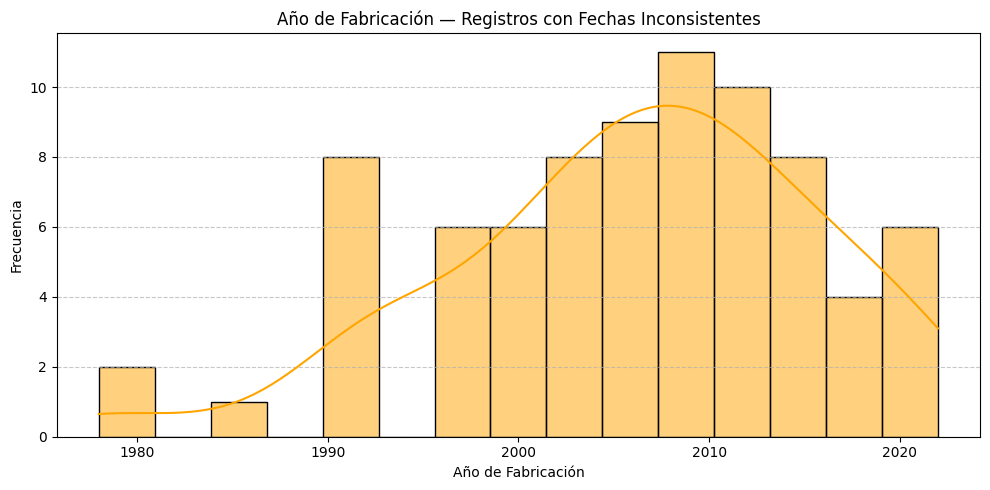

np.int64(79)

In [4]:
COLUMNAS_NUMERICAS = ['Valor_Contado', 'Total_a_Pagar', 'Ano_Fabricacion', 'Cilindrada', 'Tonelaje']

explorar_estructura(df)
analizar_categorias(df)
reporte_nulos = generar_reporte_nulos(df)
detectar_duplicados(df)
detectar_tipos_mixtos(df, COLUMNAS_NUMERICAS)
analizar_anomalias_texto(df)
validar_coherencia_fechas(df)

## 3. Limpieza de Datos

Cada función realiza un único paso. `limpiar()` los orquesta en secuencia.

**Decisiones tomadas:**
- `Equipamiento` eliminada: >55% sin información útil (nulos + valores `'EQUI'` sin definición).
- `Tonelaje` eliminada: >98% de los registros con valor `0`.
- Nulos imputados: `Combustible` y `Transmisión` por moda; `Cilindrada` por mediana del grupo (fallback a mediana global); `Codigo_SII` y `Comuna_Anterior` con etiqueta explícita.
- Texto normalizado a mayúsculas sin acentos para unificar variantes de escritura.
- Categorías consolidadas: `SEDAN` → `AUTOMOVIL`, `MOTO1`/`MOTO2` → `MOTO`, variantes de `MINIBUS`, etc.

In [5]:
# --- Helpers (uso interno) ---

def _eliminar_acentos(texto):
    if not isinstance(texto, str):
        return texto
    return "".join(
        c for c in unicodedata.normalize('NFD', texto)
        if not unicodedata.combining(c)
    )


# --- Pasos individuales de limpieza ---

def eliminar_columna_equipamiento(df):
    # >55% sin información útil (nulos + 'EQUI' sin definición)
    return df.drop(columns=['Equipamiento'])


def eliminar_columna_tonelaje(df):
    # >98% de los registros tienen valor 0, sin aporte analítico
    return df.drop(columns=['Tonelaje'])


def convertir_numericas(df):
    """Convierte a número las columnas que deberían serlo.

    Los valores que no pueden convertirse (texto mezclado) se transforman en NaN
    para que imputar_nulos los trate correctamente en el paso siguiente.
    """
    columnas = ['Valor_Contado', 'Total_a_Pagar', 'Ano_Fabricacion', 'Cilindrada']
    for col in [c for c in columnas if c in df.columns]:
        antes = df[col].isna().sum()
        df[col] = pd.to_numeric(df[col], errors='coerce')
        convertidos = df[col].isna().sum() - antes
        if convertidos > 0:
            print(f"  [!] '{col}': {convertidos} valor(es) no numérico(s) → NaN")
    return df


def imputar_nulos(df):
    df['Combustible'] = df['Combustible'].fillna(df['Combustible'].mode()[0])
    df['Transmision'] = df['Transmision'].fillna(df['Transmision'].mode()[0])
    # Cilindrada: mediana por grupo para mayor precisión; fallback a mediana global
    df['Cilindrada'] = (
        df.groupby('TipoVehiculo')['Cilindrada']
        .transform(lambda x: x.fillna(x.median()))
    )
    df['Cilindrada'] = df['Cilindrada'].fillna(df['Cilindrada'].median())
    df['Codigo_SII'] = df['Codigo_SII'].fillna('SIN_CODIGO')
    df['Comuna_Anterior'] = df['Comuna_Anterior'].fillna('OTRA')
    return df


def normalizar_texto(df):
    columnas = [
        'TipoVehiculo', 'Marca', 'Modelo', 'Combustible', 'Transmision',
        'Metodo de Pago', 'Comuna_Propietario', 'Comuna_Permiso'
    ]
    for col in columnas:
        if col in df.columns:
            # Sin astype(str): los NaN se preservan como NaN en lugar de
            # convertirse al string "nan", que engañaría a la validación final.
            df[col] = df[col].str.strip().str.upper().apply(_eliminar_acentos)
    return df


def normalizar_fechas(df):
    for col in ['Fecha_Emision', 'Fecha_Vencimiento']:
        df[col] = pd.to_datetime(df[col], errors='coerce').dt.date
    return df


def consolidar_tipo_vehiculo(df):
    mapeo = {
        'SEDAN': 'AUTOMOVIL',      'SEDAN 2': 'AUTOMOVIL',
        'SUV': 'STATION WAGON',    'SUV 2': 'STATION WAGON',
        'MOTO1': 'MOTO',           'MOTO2': 'MOTO',
        'VAN 2': 'FURGON',
        'MINIBUS PARTICULAR':          'MINIBUS',
        'MINIBUS TRANS  PASAJERO':     'MINIBUS',
        'MINIBUS TRANS PASAJERO':      'MINIBUS',
        'MINIBUS DE TURISMO':          'MINIBUS',
        'MINIBUS ESCOLAR':             'MINIBUS',
    }
    df['TipoVehiculo'] = df['TipoVehiculo'].replace(mapeo)
    return df


def consolidar_combustible_transmision(df):
    df['Transmision'] = df['Transmision'].replace({'CVT': 'AUT'})
    # 'MEC' es un error de digitación registrado en la columna Combustible
    df['Combustible'] = df['Combustible'].replace({'MEC': 'DIES'})
    return df


# --- Orquestador ---

def limpiar(df):
    """Aplica todos los pasos de limpieza en secuencia."""
    df = df.copy()
    df = eliminar_columna_equipamiento(df)
    df = eliminar_columna_tonelaje(df)
    df = convertir_numericas(df)
    df = imputar_nulos(df)
    df = normalizar_texto(df)
    df = normalizar_fechas(df)
    df = consolidar_tipo_vehiculo(df)
    df = consolidar_combustible_transmision(df)
    print(f"Limpieza completada — {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

In [6]:
df_clean = limpiar(df)

display(df_clean.head(5))
display(df_clean.describe())

Limpieza completada — 3195 filas x 19 columnas


,_id,Fecha_Emision,Ano_Proceso,Metodo de Pago,Cuotas Permiso,Codigo_SII,Comuna_Propietario,Comuna_Permiso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,TipoVehiculo,Marca,Modelo,Cilindrada,Combustible,Transmision,Comuna_Anterior,Fecha_Vencimiento
0,1,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2026-03-31
1,2,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2027-03-31
2,3,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2024-03-31
3,4,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2025-03-31
4,5,2026-04-08,2026,PRESENCIAL,Total,SIN_CODIGO,COYHAIQUE,RIO IBANEZ,137846,145072,1988,CAMION,MERCEDES BENZ,L1114 48,3625,DIES,MEC,RIO BUENO,2026-09-30


,_id,Ano_Proceso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,Cilindrada
count,3195,3195,3195,3195,3195,3195
mean,1598,2026,121167,87864,2017,2286
std,922,0,146414,116250,9,750
min,1,2026,23115,0,1970,100
25%,800,2026,34876,34876,2011,2000
50%,1598,2026,69694,50828,2020,2400
75%,2396,2026,169682,95809,2023,2500
max,3195,2026,1995056,1746213,2026,7500


## 4. Transformación
Normalización de nombres de columnas a `snake_case` para consistencia en el acceso programático.

In [7]:
def _a_snake_case(nombre):
    s = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', nombre)
    s = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s).lower()
    return s.replace(' ', '_').replace('.', '').replace('__', '_').strip('_')


def renombrar_columnas(df):
    """Convierte los nombres de columnas al formato snake_case."""
    df = df.copy()
    df.columns = [_a_snake_case(col) for col in df.columns]
    return df


def transformar(df):
    """Aplica todas las transformaciones estructurales al dataset."""
    df = renombrar_columnas(df)
    print(f"Transformación completada — columnas: {df.columns.tolist()}")
    return df

In [8]:
df_clean = transformar(df_clean)

display(df_clean.head(5))

Transformación completada — columnas: ['id', 'fecha_emision', 'ano_proceso', 'metodo_de_pago', 'cuotas_permiso', 'codigo_sii', 'comuna_propietario', 'comuna_permiso', 'valor_contado', 'total_a_pagar', 'ano_fabricacion', 'tipo_vehiculo', 'marca', 'modelo', 'cilindrada', 'combustible', 'transmision', 'comuna_anterior', 'fecha_vencimiento']


,id,fecha_emision,ano_proceso,metodo_de_pago,cuotas_permiso,codigo_sii,comuna_propietario,comuna_permiso,valor_contado,total_a_pagar,ano_fabricacion,tipo_vehiculo,marca,modelo,cilindrada,combustible,transmision,comuna_anterior,fecha_vencimiento
0,1,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2026-03-31
1,2,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2027-03-31
2,3,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2024-03-31
3,4,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2025-03-31
4,5,2026-04-08,2026,PRESENCIAL,Total,SIN_CODIGO,COYHAIQUE,RIO IBANEZ,137846,145072,1988,CAMION,MERCEDES BENZ,L1114 48,3625,DIES,MEC,RIO BUENO,2026-09-30


## 5. Validación y Exportación
Verificaciones automáticas (`assert`) para garantizar la integridad del dataset antes de exportar.

In [9]:
def validar(df, anio_actual=2026):
    """Verifica que el dataset cumple condiciones mínimas de calidad antes de exportar."""
    assert df.isna().sum().sum() == 0,                              "Existen valores nulos"
    assert not df.duplicated().any(),                               "Existen filas duplicadas"
    assert df['ano_fabricacion'].between(1900, anio_actual).all(),  "Años de fabricación fuera de rango"
    assert (df['cilindrada'] >= 0).all(),                           "Cilindradas negativas detectadas"
    print("Todas las validaciones pasaron correctamente.")
    return df


def exportar(df, ruta='datos/resultado/df_clean.csv'):
    """Guarda el dataset procesado en disco."""
    os.makedirs(os.path.dirname(ruta), exist_ok=True)
    df.to_csv(ruta, index=False, encoding='utf-8')
    kb = os.path.getsize(ruta) / 1024
    print(f"Dataset exportado → {ruta}  ({kb:.1f} KB | {df.shape[0]} filas x {df.shape[1]} columnas)")

In [10]:
df_clean = validar(df_clean)
exportar(df_clean)

print("\n--- Estructura final del dataset ---")
display(df_clean.info())
display(df_clean.head(5))

Todas las validaciones pasaron correctamente.
Dataset exportado → datos/resultado/df_clean.csv  (497.8 KB | 3195 filas x 19 columnas)

--- Estructura final del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3195 entries, 0 to 3194
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  3195 non-null   int64  
 1   fecha_emision       3195 non-null   object 
 2   ano_proceso         3195 non-null   int64  
 3   metodo_de_pago      3195 non-null   object 
 4   cuotas_permiso      3195 non-null   object 
 5   codigo_sii          3195 non-null   object 
 6   comuna_propietario  3195 non-null   object 
 7   comuna_permiso      3195 non-null   object 
 8   valor_contado       3195 non-null   int64  
 9   total_a_pagar       3195 non-null   int64  
 10  ano_fabricacion     3195 non-null   int64  
 11  tipo_vehiculo       3195 non-null   object 
 12  marca               3195 non-n

None

,id,fecha_emision,ano_proceso,metodo_de_pago,cuotas_permiso,codigo_sii,comuna_propietario,comuna_permiso,valor_contado,total_a_pagar,ano_fabricacion,tipo_vehiculo,marca,modelo,cilindrada,combustible,transmision,comuna_anterior,fecha_vencimiento
0,1,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2026-03-31
1,2,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2027-03-31
2,3,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2024-03-31
3,4,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2025-03-31
4,5,2026-04-08,2026,PRESENCIAL,Total,SIN_CODIGO,COYHAIQUE,RIO IBANEZ,137846,145072,1988,CAMION,MERCEDES BENZ,L1114 48,3625,DIES,MEC,RIO BUENO,2026-09-30
